In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
import os, io
import json
import logging
from warnings import filterwarnings

from data.lucas_descriptions import data_gdf_description
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage, HuggingFaceLLMClient
from utils.llm_api.query import QueryProvider, QueryType
from utils.extraction import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)

## needed for running solution
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

filterwarnings("ignore")

In [103]:
exec_needed_imports = """
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
"""

### Loading map of Europe

In [104]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[(world_gdf['EU_STAT'] == 'T') | (world_gdf['CNTR_ID'] == 'UK')]
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

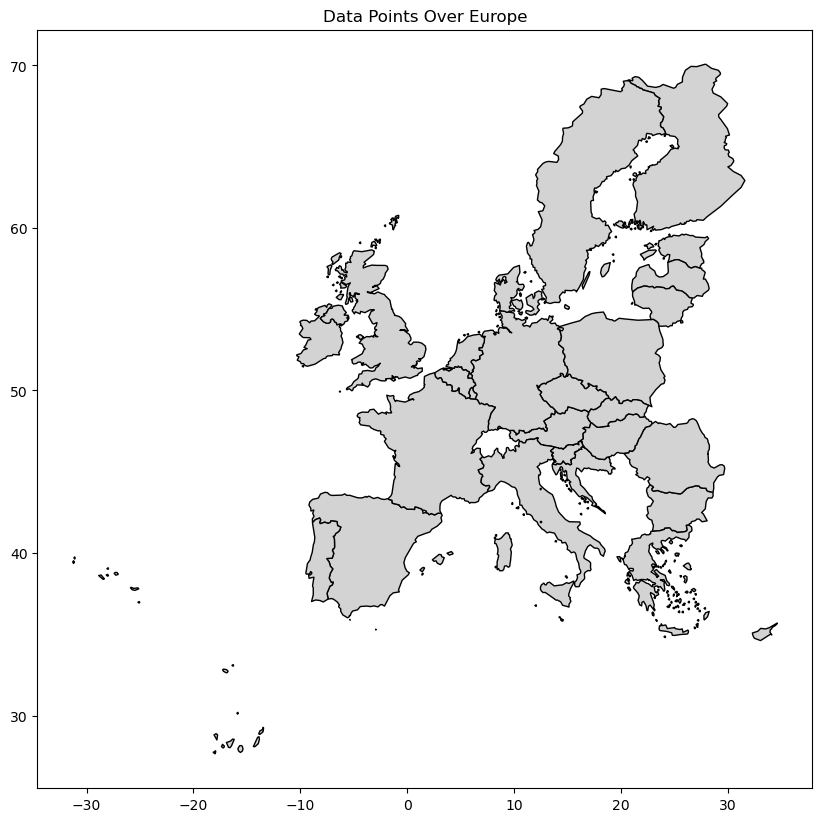

In [105]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

In [106]:
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

### LLM setup

In [107]:
llm_client = GPT4AllClient()

In [108]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'DeepSeek-R1-Distill-Llama-8B',
 'Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [109]:
MODEL_NAME_INSTRUCTOR = available_models[4]
MODEL_NAME_CODER = available_models[4]
MODEL_NAME_CORRECTOR = available_models[4]

client_instructor = GPT4AllClient(model_name=MODEL_NAME_CODER)
client_corrector = GPT4AllClient(model_name=MODEL_NAME_CORRECTOR)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [110]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

In [111]:
categorical_columns = ['Depth', 'NUTS_0', 'LC0_Desc', 'Country']

In [112]:
categorical_columns_values = ""
for categorical_column in categorical_columns:
    categorical_columns_values += f"{categorical_column}: {data_gdf[categorical_column].unique()}\n"

In [113]:
print(categorical_columns_values)

Depth: ['0-20 cm' '0-10 cm' '10-20 cm' '20-30 cm']
NUTS_0: ['AT' 'PT' 'ES' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'FR' 'UK' 'FI'
 'SE' 'SI' 'IT' 'HR' 'HU' 'IE' 'LT' 'LU' 'LV' 'MT' 'NL' 'PL' 'RO' 'SK']
LC0_Desc: ['Woodland' 'Cropland' 'Grassland' 'Bareland' 'Shrubland'
 'Artificial land' 'Wetlands' 'Water']
Country: ['Austria' 'Portugal' 'Spain' 'Belgium' 'Bulgaria' 'Cyprus'
 'Czech Republic' 'Germany' 'Denmark' 'Estonia' 'Greece' 'France'
 'United Kingdom' 'Finland' 'Sweden' 'Slovenia' 'Italy' 'Croatia'
 'Hungary' 'Ireland' 'Lithuania' 'Luxembourg' 'Latvia' 'Malta'
 'Netherlands' 'Poland' 'Romania' 'Slovakia']



In [114]:
model_id = MODEL_NAME_CODER
BASE_QUERY_DIR = './data/user_query_adjusted/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = f'./data/generated/{model_id}/'
BASE_METRICS_DIR = f'./data/metrics/{model_id}/'

In [115]:
def exec_solution(solution_function_string):
    if solution_function_string is None:
        print("No solution provided.")
        return
    
    local_scope = {}
    exec(
        exec_needed_imports + "\n" + \
        solution_function_string + "\n\n" + \
        "solve(data_gdf, europe_gdf)", 
        globals(), local_scope
    )

In [116]:
def run_test(objective: str):
    solution_function_string = None
    try:
        solution_function_string = run_pipeline(
            objective=objective,
            client_instructor=client_instructor,
            client_corrector=client_corrector,
            client_coder=client_coder,
            data_gdf=data_gdf,
            data_gdf_description=data_gdf_description,
            europe_gdf=europe_gdf,
            europe_gdf_description=europe_gdf_description,
            retry_count=3,
            categorical_columns_values=categorical_columns_values
        )
    except Exception as e:
        logging.error(e)
        
    if solution_function_string is None:
        try:
            solution_function_string = run_pipeline(
                objective=objective,
                client_instructor=client_instructor,
                client_corrector=client_corrector,
                client_coder=client_coder,
                data_gdf=data_gdf,
                data_gdf_description=data_gdf_description,
                europe_gdf=europe_gdf,
                europe_gdf_description=europe_gdf_description,
                retry_count=1,
                categorical_columns_values=categorical_columns_values
            )
        except Exception as e:
            logging.error(e)
            
    return solution_function_string
    

In [117]:
geo_queries = []
for query_type in ['geo']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        geo_queries.append(query)

# 1. query

In [60]:
geo_queries[0]

'Can you plot the locations of all points where the pH_CaCl2 is greater than 6 on a map, and save the image as a PNG file?'

2025-02-04 23:44:56,808 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_CaCl2 is greater than 6
filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Create a new GeoDataFrame with the filtered data and save it as 'transformed_gdf'
transformed_gdf = pd.DataFrame(filtered_gdf)
```
2025-02-04 23:44:59,295 - Query finished successfully, response: 
map
2025-02-04 23:45:13,631 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the map of Europe with black borders and light gray fill color
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter data from 'transformed_gdf' where pH_CaCl2 is greater than 6
filtered_data = transformed_gdf[transformed_gdf['pH_CaCl2'] > 6]

# Plot the filtered locations as markers on top of the map, with size 5 and color blue
filtered_data.plot(ax=ax, column='geometry', m

Error in callback <function _draw_all_if_interactive at 0x0000020792309120> (for post_execute), with arguments args (),kwargs {}:


ValueError: Date ordinal -3249141.35 converts to -6926-02-25T15:36:00.000000 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

ValueError: Date ordinal -3249141.35 converts to -6926-02-25T15:36:00.000000 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 1000x800 with 1 Axes>

ValueError: Date ordinal -3249141.35 converts to -6926-02-25T15:36:00.000000 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 1000x800 with 1 Axes>

ValueError: Date ordinal -3249141.35 converts to -6926-02-25T15:36:00.000000 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 1000x800 with 1 Axes>

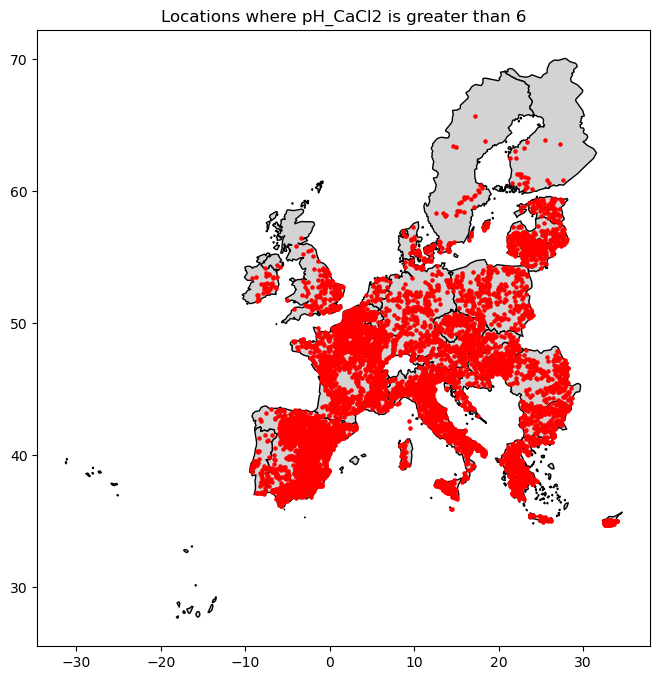

In [61]:
solution_function_string = run_test(geo_queries[0])

In [62]:
print(clean_python_code(solution_function_string))

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_gdf[transformed_gdf['pH_CaCl2'] > 6].plot(ax=ax, column='geometry', marker='o', color='red', markersize=5)
	ax.set_title('Locations where pH_CaCl2 is greater than 6')
	plt.savefig('pH_CaCl2_greater_than_6.png')


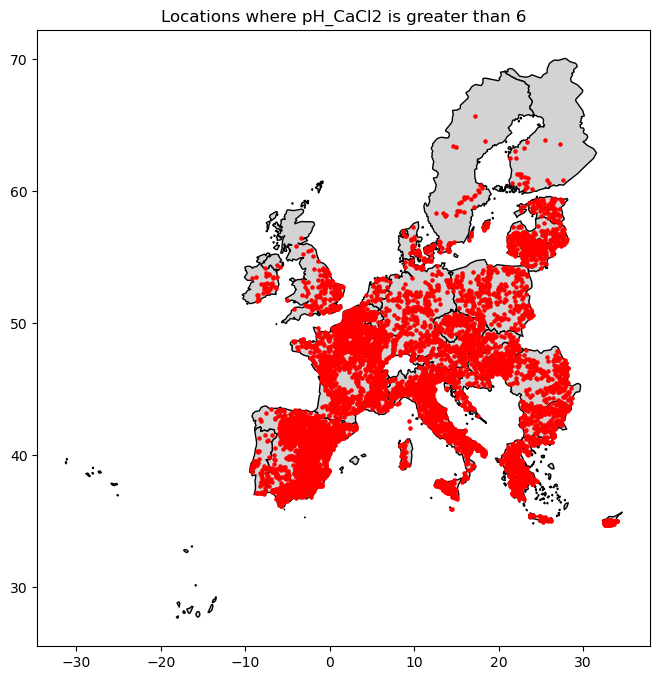

In [63]:
exec_solution(solution_function_string)

# 2. query

In [64]:
geo_queries[1]

"Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20 on the map, and save the map as a png."

2025-02-04 23:46:40,901 - Query finished successfully, response: 
```python
# Filter the data for LC0_Desc='Grassland' and LC0_Desc='Woodland'
filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
    
# Select only points where OC > 20
transformed_gdf = filtered_gdf[filtered_gdf['OC'] > 20]
```
2025-02-04 23:46:43,395 - Query finished successfully, response: 
map
2025-02-04 23:46:59,313 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter data to plot only 'Grassland' and 'Woodland' points with OC > 20
filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
filtered_data = filtered_data[filtered_data['OC'] > 20]

# Plot the filtered data as markers

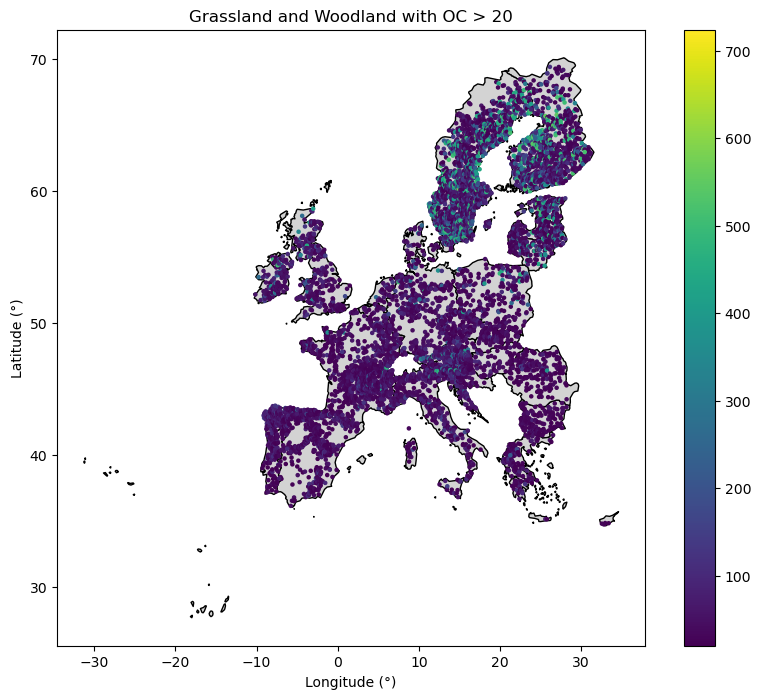

In [65]:
solution_function_string = run_test(geo_queries[1])

In [66]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
	transformed_gdf = filtered_gdf[filtered_gdf['OC'] > 20]
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
	filtered_data = filtered_data[filtered_data['OC'] > 20]
	filtered_data.plot(ax=ax, column='OC', legend=True, marker='o', markersize=5)
	ax.set_title('Grassland and Woodland with OC > 20')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	plt.savefig('grassland_woodland_oc.png', bbox_inches='tight')


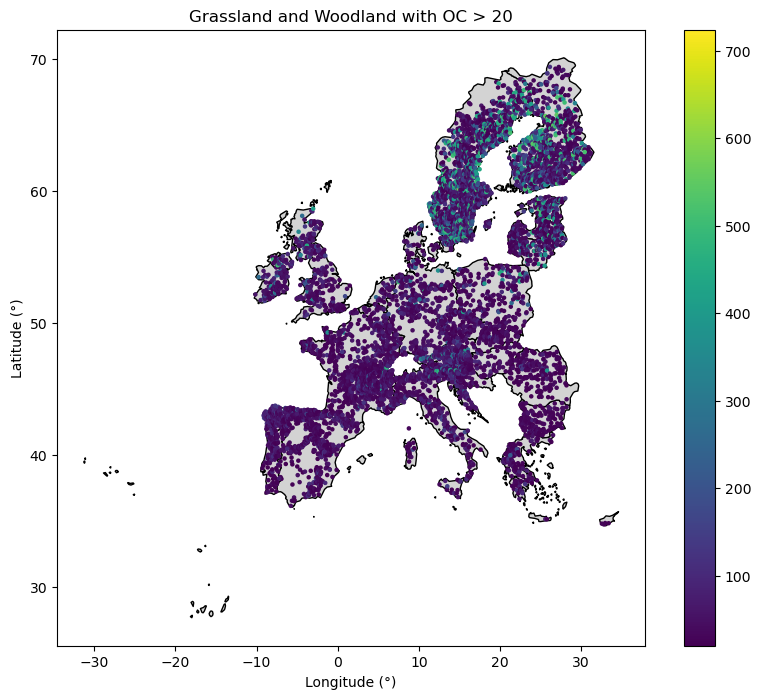

In [67]:
exec_solution(solution_function_string)

# 3. query

In [68]:
geo_queries[2]

'Can you plot the locations where LC0_Desc=Woodland on the map, and save the it as a PNG file?'

2025-02-04 23:47:18,198 - Query finished successfully, response: 
```python
# Filter the data to include only rows where LC0_Desc equals 'Woodland'
woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Save the filtered GeoDataFrame as a PNG file
import fiona
from shapely.geometry import shape

with fiona.open('path_to_your_shapefile.shp') as src:
    schema = src.schema
woodland_gdf.to_crs(epsg=4326, inplace=True)
woodland_gdf['geometry'] = woodland_gdf.apply(lambda row: shape(row.geometry), axis=1)

# Save the filtered GeoDataFrame to a new ShapeFile
with fiona.open('path_to_output.shp', 'w', driver='ESRI Shapefile', crs={'init': 'EPSG:4326'}, schema=schema) as dst:
    for feature in woodland_gdf.geometry.apply(lambda x: {'geometry':x, 'properties':None}).values.tolist():
        dst.write({'geometry':feature['geometry'], 'type':'Feature','properties':feature['properties']})
```
2025-02-04 23:47:18,210 - GDAL signalled an error: err_no=4, msg='path_to_your_shapefile.shp: No

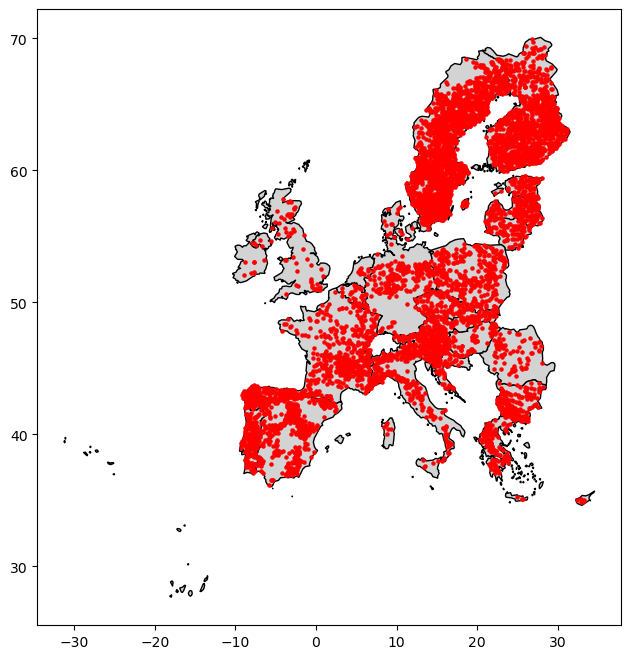

In [69]:
solution_function_string = run_test(geo_queries[2])

In [70]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	woodland_data = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
	transformed_gdf = woodland_data.copy()
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_gdf.loc[transformed_gdf['LC0_Desc'] == 'Woodland'].plot(ax=ax, column=None, marker='o', color='red', markersize=5)
	plt.show()
	fig.savefig('woodlands_europe.png')


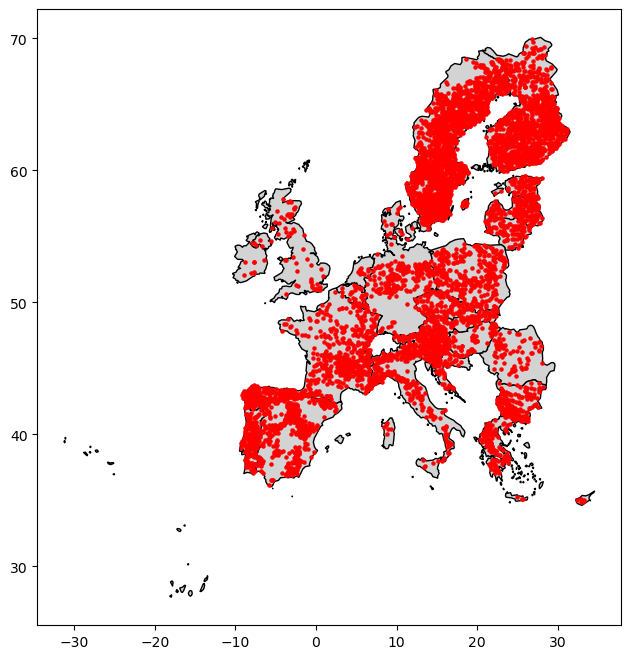

In [71]:
exec_solution(solution_function_string)

# 4. query

In [72]:
geo_queries[3]

'Plot all the points where LC0_Desc=Woodland and pH<6 on the map, and save the result as a png.'

2025-02-04 23:48:10,832 - Query finished successfully, response: 
```python
# Filter the data to include only rows where LC0_Desc equals 'Woodland'
woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Filter the woodland data further to include only rows where pH < 6
low_pH_woodland_gdf = woodland_gdf[woodland_gdf['pH_H2O'] < 6]

# Save the result as a new GeoDataFrame called transformed_gdf
transformed_gdf = low_pH_woodland_gdf.copy()
```
2025-02-04 23:48:13,259 - Query finished successfully, response: 
map
2025-02-04 23:48:31,026 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter transformed data to plot only points where LC0_Desc=Woodland and pH<6
woodland_points = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed

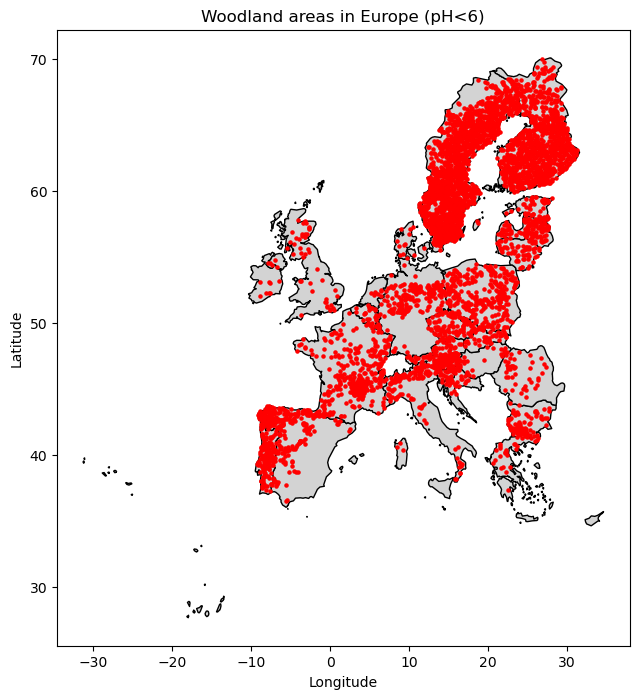

In [73]:
solution_function_string = run_test(geo_queries[3])

In [74]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
	low_pH_woodland_gdf = woodland_gdf[woodland_gdf['pH_H2O'] < 6]
	transformed_gdf = low_pH_woodland_gdf.copy()
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	woodland_points = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed_gdf['pH_H2O'] < 6)]
	woodland_points.plot(ax=ax, marker='o', color='red', markersize=5)
	ax.set_title('Woodland areas in Europe (pH<6)')
	ax.set_xlabel('Longitude')
	ax.set_ylabel('Latitude')
	plt.savefig('woodland_points.png', bbox_inches='tight')


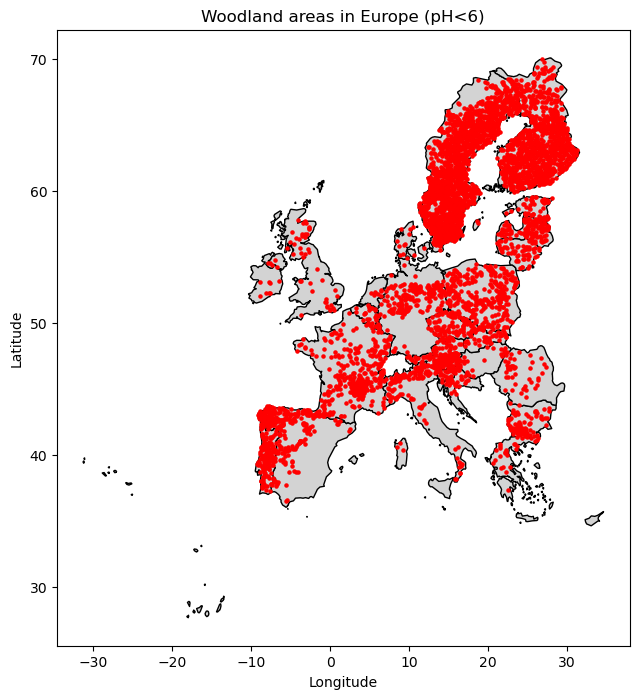

In [75]:
exec_solution(solution_function_string)

# 5. query

In [76]:
geo_queries[4]

'Can you use KMeans clustering to group geographic points based on latitude and longitude into three clusters, plot them on a map, and save the result as a PNG file?'

2025-02-04 23:48:48,265 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd
from sklearn.cluster import KMeans

# Select the columns of interest for clustering (latitude and longitude)
transformed_gdf = data_gdf[['TH_LAT', 'TH_LONG']]

# Scale latitude and longitude values to a common range (0-1) using Min-Max Scaler from scikit-learn
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(transformed_gdf)

# Perform KMeans clustering with 3 clusters on the scaled data
kmeans = KMeans(n_clusters=3)
cluster_labels = kmeans.fit_predict(scaled_data)

# Create a new column in 'transformed_gdf' to store cluster labels
transformed_gdf['Cluster'] = cluster_labels

# Save the transformed GeoDataFrame as a PNG file (not applicable here, but kept for completeness)
# Note: The actual saving of the map would require additional libraries like geopandas and matplotlib.
```
2025-02-04 23:48:50,802 - Que

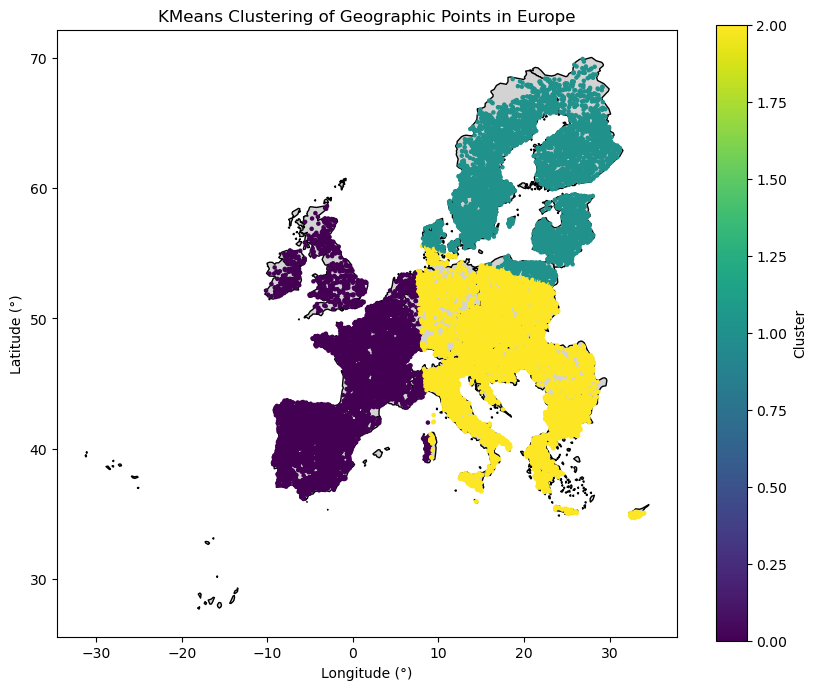

In [77]:
solution_function_string = run_test(geo_queries[4])

In [78]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	import pandas as pd
	from sklearn.cluster import KMeans
	transformed_gdf = data_gdf[['TH_LAT', 'TH_LONG']]
	from sklearn.preprocessing import MinMaxScaler
	scaler = MinMaxScaler()
	scaled_data = scaler.fit_transform(transformed_gdf)
	kmeans = KMeans(n_clusters=3)
	cluster_labels = kmeans.fit_predict(scaled_data)
	transformed_gdf['Cluster'] = cluster_labels
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	from sklearn.cluster import KMeans
	kmeans = KMeans(n_clusters=3)
	transformed_gdf['Cluster'] = kmeans.fit_predict(transformed_gdf[['TH_LAT', 'TH_LONG']].values)
	plt.scatter(transformed_gdf['TH_LONG'], transformed_gdf['TH_LAT'], c=transformed_gdf['Cluster'], s=5)
	plt.colorbar(label='Cluster')
	ax.set_title('KMeans Clustering of Geographic Points in Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	fig.save

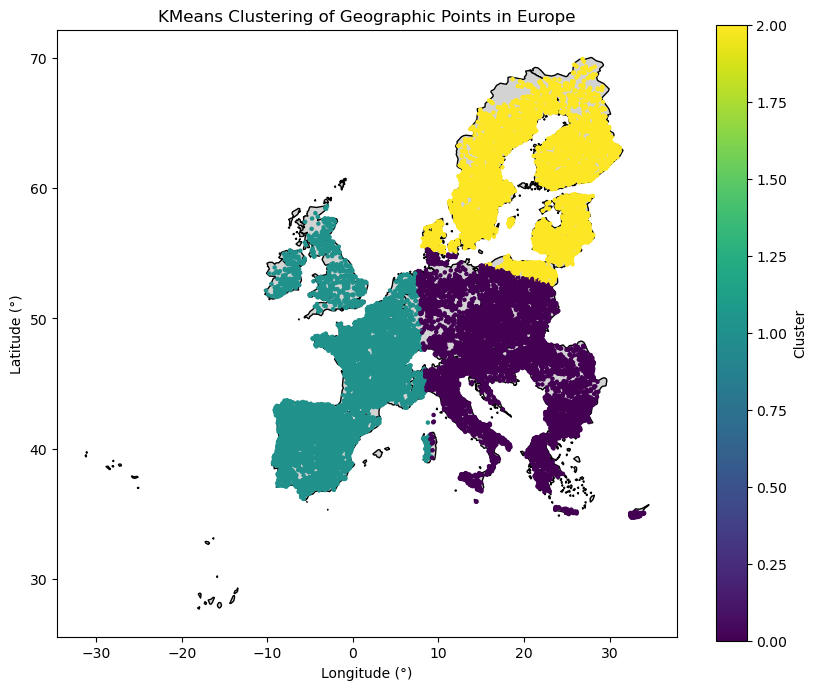

In [79]:
exec_solution(solution_function_string)

# 6. query

In [80]:
geo_queries[5]

'Can you create a map showing locations where potassium (K) levels are above the median, and save the map as a PNG file?'

2025-02-04 23:49:21,037 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to select only rows where K levels are above median and Depth is '0-10 cm'
transformed_gdf = data_gdf[(data_gdf['K'] > data_gdf['K'].median()) & (data_gdf['Depth'] == '0_10')]

# Save the transformed GeoDataFrame as a PNG file
# Note: Since you don't have access to visualization libraries, this line will be commented out.
# However, it's included for completeness and would typically involve using a library like geopandas or matplotlib.
#transformed_gdf.to_file('potassium_above_median.png', driver='PNG')
```
2025-02-04 23:49:23,433 - Query finished successfully, response: 
map
2025-02-04 23:49:37,463 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black'

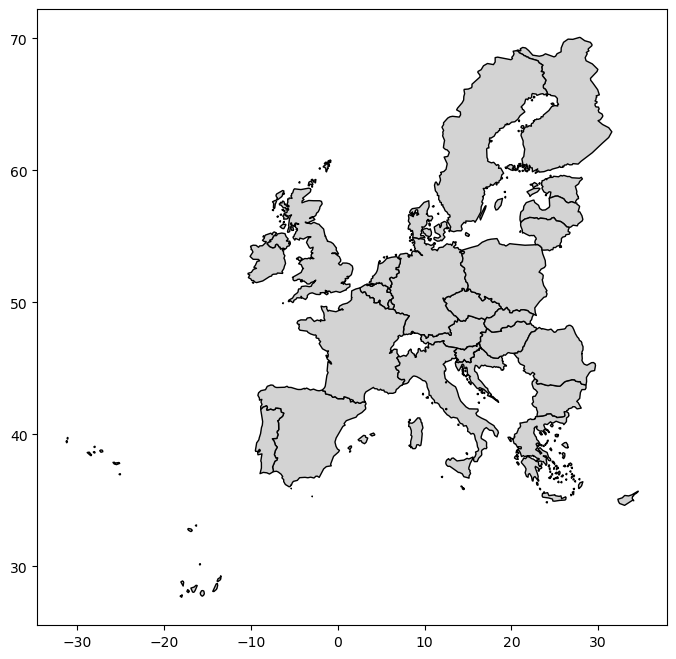

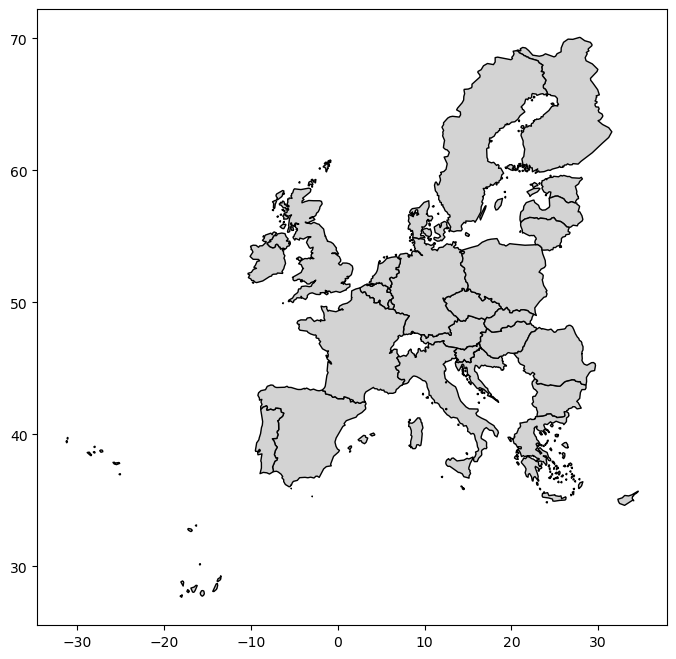

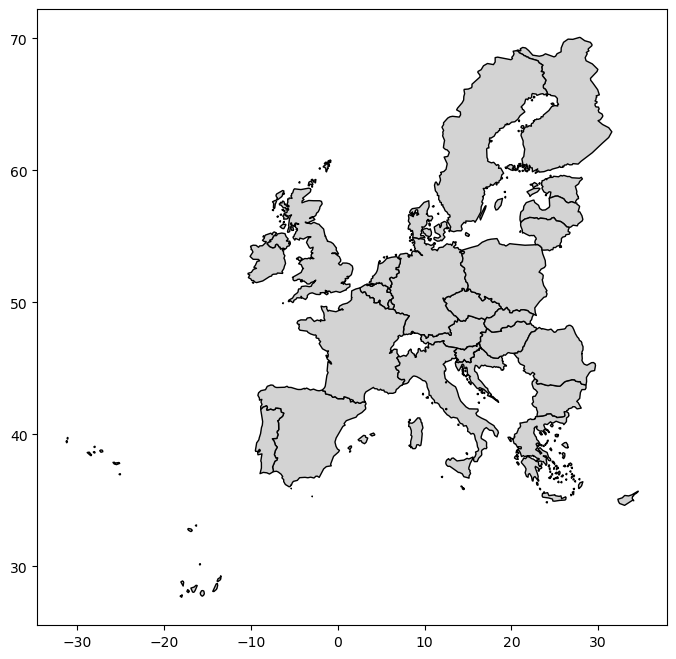

In [81]:
solution_function_string = run_test(geo_queries[5])

In [82]:
print(solution_function_string)

None


In [83]:
exec_solution(solution_function_string)

No solution provided.


# 7. query

In [84]:
geo_queries[6]

"Can you create a map showing soil pH_CaCl2 levels across Europe? I'd like the dots to be colored by pH_CaCl2 values, and save it as an image."

2025-02-04 23:50:36,143 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only rows where pH_CaCl2 is available (not NaN)
transformed_gdf = data_gdf.dropna(subset=['pH_CaCl2'])

# Create a new column 'color' based on pH_CaCl2 values, ranging from blue for low pH to red for high pH
transformed_gdf['color'] = pd.cut(transformed_gdf['pH_CaCl2'], bins=[0, 4.5, 7.5, 10], labels=['blue', 'green', 'red'])

# Save the transformed data as a new GeoDataFrame
```
2025-02-04 23:50:38,707 - Query finished successfully, response: 
map
2025-02-04 23:50:50,617 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Plot locations from transformed_gdf on top of the base map
transformed_gdf.plot(ax=ax, column='

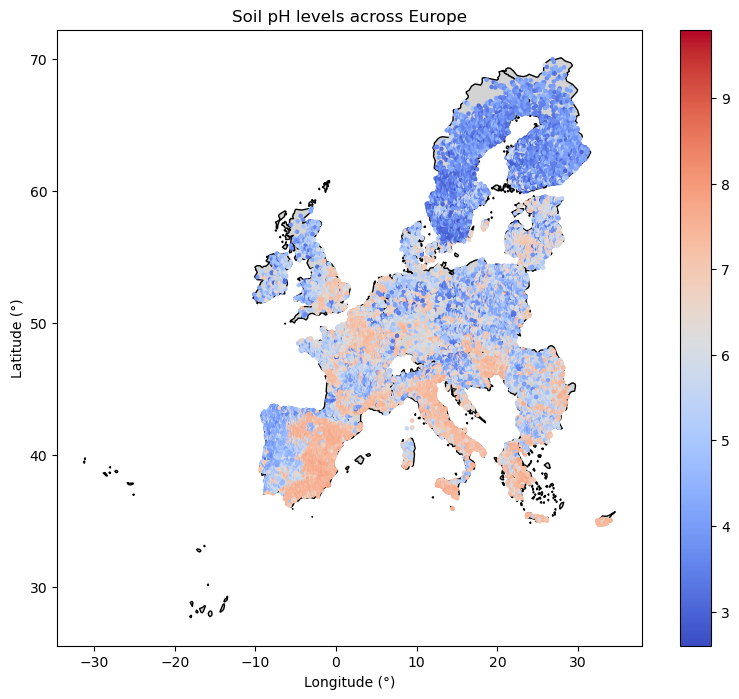

In [85]:
solution_function_string = run_test(geo_queries[6])

In [86]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	import pandas as pd
	transformed_gdf = data_gdf.dropna(subset=['pH_CaCl2'])
	transformed_gdf['color'] = pd.cut(transformed_gdf['pH_CaCl2'], bins=[0, 4.5, 7.5, 10], labels=['blue', 'green', 'red'])
	import matplotlib.pyplot as plt
	fig, ax = plt.subplots(figsize=(10, 8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_gdf.plot(ax=ax, column='pH_CaCl2', markersize=5, cmap='coolwarm', legend=True)
	ax.set_title('Soil pH levels across Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	plt.savefig('soil_pH_levels_europe.png')


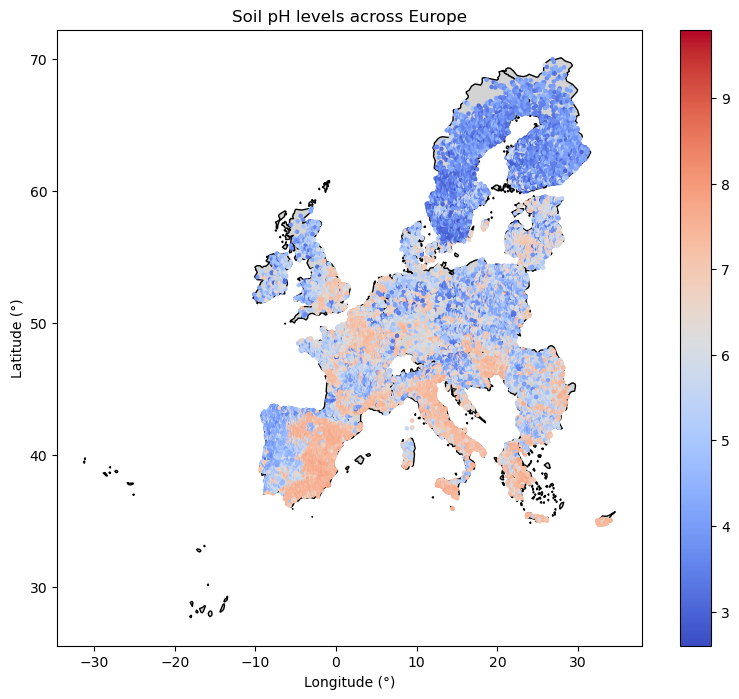

In [87]:
exec_solution(solution_function_string)

# 8. query

In [88]:
geo_queries[7]

"Can you show me a map of Europe marking only the locations with the highest potassium ('K') levels? Just highlight the top 10% of spots and save it as an image."

2025-02-04 23:51:03,187 - Query finished successfully, response: 
```python
# Filter the data to include only rows where 'K' is not missing and greater than 0
transformed_gdf = data_gdf[data_gdf['K'] > 0]

# Calculate the top 10% of potassium levels
max_k = transformed_gdf['K'].quantile(0.9)
top_10_percent = transformed_gdf[transformed_gdf['K'] >= max_k]
```
2025-02-04 23:51:05,693 - Query finished successfully, response: 
map
2025-02-04 23:51:23,275 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Get the top 10% of locations with highest potassium ('K') levels
top_10_percent = transformed_gdf.nlargest(0.1, 'K')

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(12,8))

# Plot Europe map as background
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Overlay top 10% of locations with highest potassium ('K') levels on the map
top_10_percent.plot(ax=ax, column='K', markersize=5, legend=True)

# Set title an

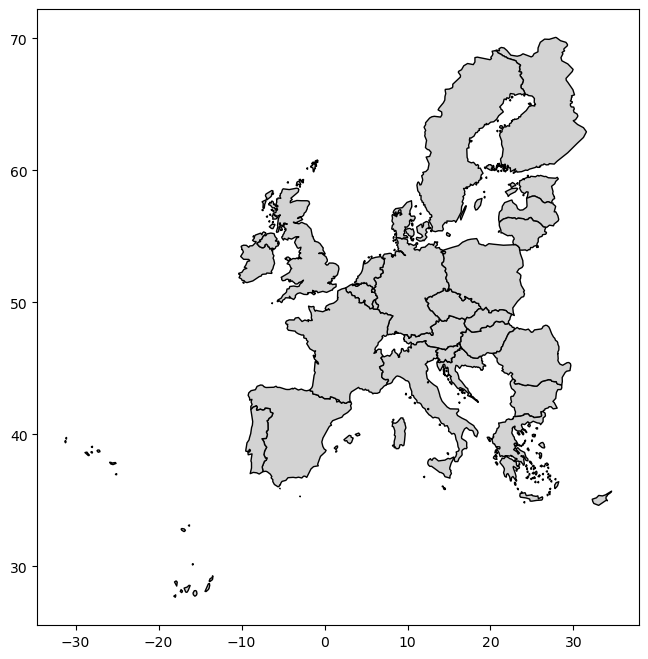

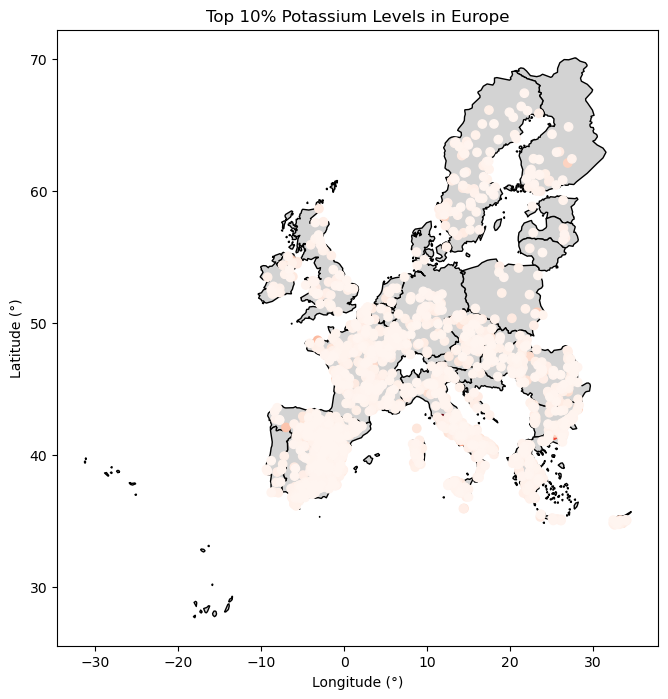

In [89]:
solution_function_string = run_test(geo_queries[7])

In [90]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	transformed_gdf = data_gdf[data_gdf['K'] > 0]
	max_k = transformed_gdf['K'].quantile(0.9)
	top_10_percent = transformed_gdf[transformed_gdf['K'] >= max_k]
	import matplotlib.pyplot as plt
	top_10_percent = transformed_gdf.nlargest(int(0.1 * len(transformed_gdf)), 'K')
	fig, ax = plt.subplots(figsize=(12,8))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	top_10_percent.plot(ax=ax, column='geometry', markersize=5, marker='o', color='red')
	ax.scatter(top_10_percent.geometry.x, top_10_percent.geometry.y, c=top_10_percent['K'], cmap='Reds')
	ax.set_title('Top 10% Potassium Levels in Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	plt.show()


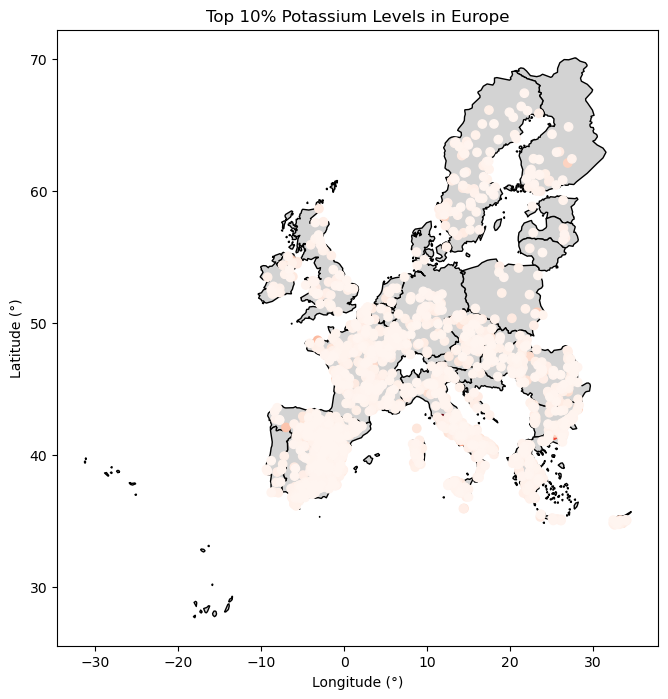

In [91]:
exec_solution(solution_function_string)

# 9. query

In [118]:
geo_queries[8]

'Could you make a map showing where soil pH_H2O levels in Europe are acidic versus basic? Mark acidic spots in red and basic spots in blue, and save it as an image.'

2025-02-04 23:56:15,852 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_H2O is less than 7 (acidic) or greater than 7 (basic)
data_gdf = data_gdf[(data_gdf['pH_H2O'] < 7) | (data_gdf['pH_H2O'] > 7)]

# Create a new column 'soil_type' based on the pH_H2O value
data_gdf['soil_type'] = np.where(data_gdf['pH_H2O'] < 7, 'acidic', 'basic')

# Save the transformed data to a new GeoDataFrame called 'transformed_gdf'
transformed_gdf = data_gdf.copy()
```
2025-02-04 23:56:18,385 - Query finished successfully, response: 
map
2025-02-04 23:56:45,315 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Plot locations from 'transformed_gdf' on top of the European map
transformed_gdf.plot(ax=ax, column='pH_H2O', legend=True

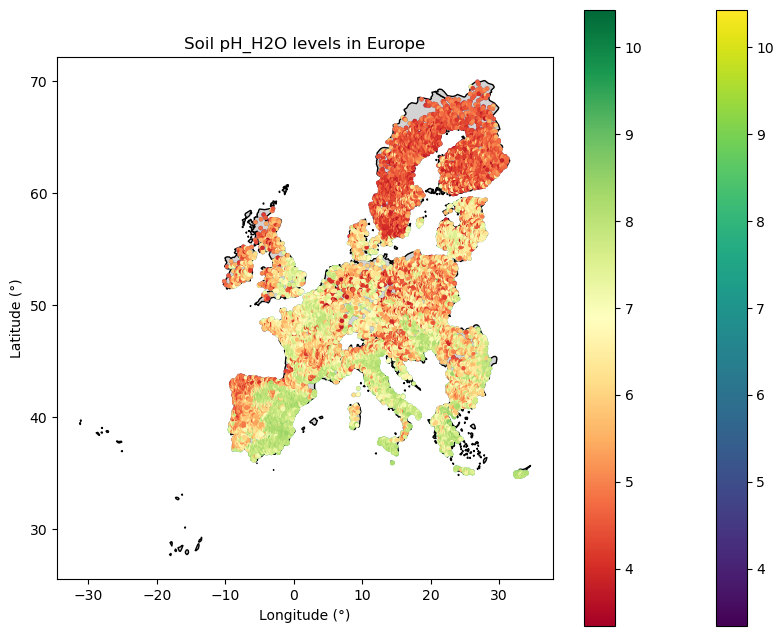

In [119]:
solution_function_string = run_test(geo_queries[8])

In [122]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only rows where pH_H2O is less than 7 (acidic) or greater than 7 (basic)
	data_gdf = data_gdf[(data_gdf['pH_H2O'] < 7) | (data_gdf['pH_H2O'] > 7)]
	# Create a new column 'soil_type' based on the pH_H2O value
	data_gdf['soil_type'] = np.where(data_gdf['pH_H2O'] < 7, 'acidic', 'basic')
	# Save the transformed data to a new GeoDataFrame called 'transformed_gdf'
	transformed_gdf = data_gdf.copy()
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Plot locations from 'transformed_gdf' on top of the European map
	transformed_gdf.plot(ax=ax, column='pH_H2O', legend=True,
	                      markersize=5, categorical=False)
	# Set a colormap for pH_H2O levels (acidic to basic)
	cmap = plt.get_cmap('RdYlGn')  # Red

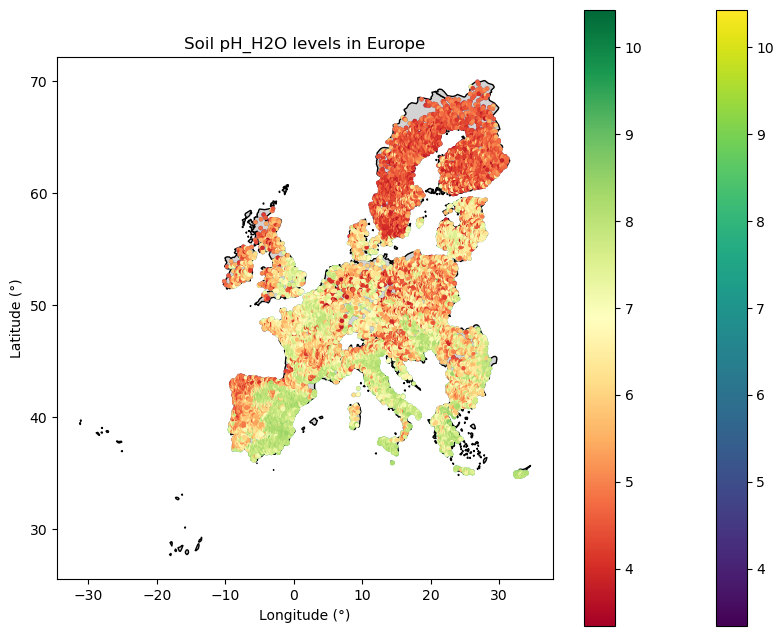

In [123]:
exec_solution(solution_function_string)

# 10. query

In [124]:
geo_queries[9]

"Can you create a colorful map showing different types of soil by 'LC0_Desc' across Europe? I'd like each soil type marked in a different color and saved as an image."

2025-02-04 23:57:54,871 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only rows where LC0_Desc is not null and equals 'Woodland'
transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland')]

# Create a new column 'color' based on the unique values in LC0_Desc
transformed_gdf['color'] = transformed_gdf['LC0_Desc']

# Map each soil type to a different color using a dictionary
soil_colors = {
    'Cropland': '#FF0000',  # Red for Cropland
    'Grassland': '#008000',  # Green for Grassland
    'Bareland': '#808080',   # Grey for Bareland
    'Shrubland': '#800080',  # Purple for Shrubland
    'Artificial land': '#FFA500',  # Orange for Artificial land
    'Wetlands': '#0000FF',     # Blue for Wetlands
    'Water': '#C0C0C0'        # Light Grey for Water
}

# Apply the color mapping to the transformed_gdf GeoDataFrame
transformed_gdf['color'] = transformed_gdf['LC0_Desc'

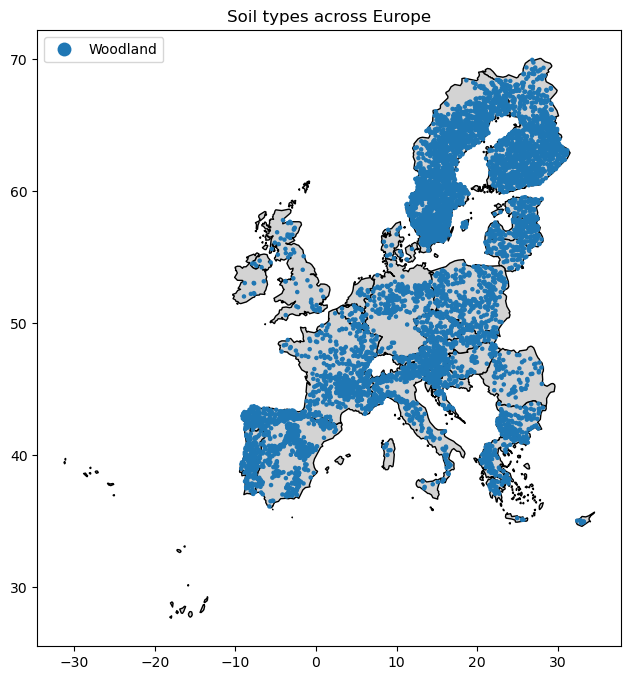

In [125]:
solution_function_string = run_test(geo_queries[9])

In [126]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	import pandas as pd
	# Filter the data to include only rows where LC0_Desc is not null and equals 'Woodland'
	transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland')]
	# Create a new column 'color' based on the unique values in LC0_Desc
	transformed_gdf['color'] = transformed_gdf['LC0_Desc']
	# Map each soil type to a different color using a dictionary
	soil_colors = {
	    'Cropland': '#FF0000',  # Red for Cropland
	    'Grassland': '#008000',  # Green for Grassland
	    'Bareland': '#808080',   # Grey for Bareland
	    'Shrubland': '#800080',  # Purple for Shrubland
	    'Artificial land': '#FFA500',  # Orange for Artificial land
	    'Wetlands': '#0000FF',     # Blue for Wetlands
	    'Water': '#C0C0C0'        # Light Grey for Water
	}
	# Apply the color mapping to the transformed_gdf GeoDataFrame
	transformed_gdf['color'] = transformed_gdf['LC

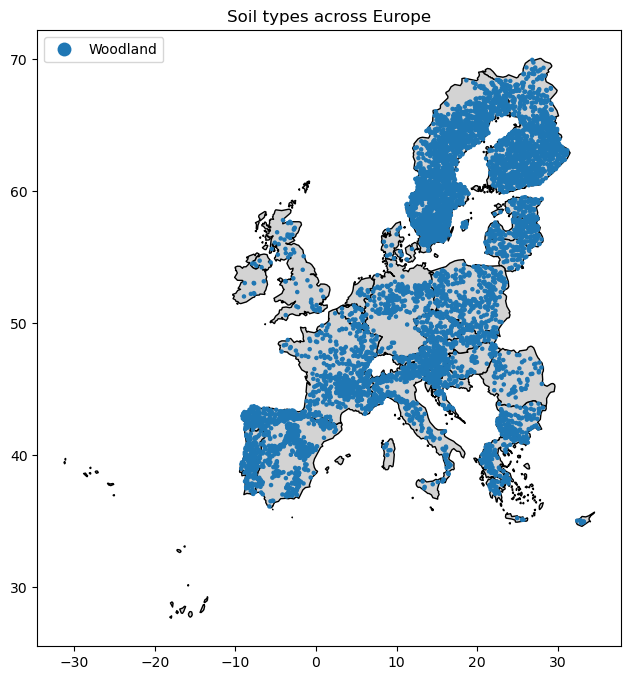

In [127]:
exec_solution(solution_function_string)

In [100]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

### Testing on all queries

Processing 10 infer queries

QUERY:  Does 'pH_H2O' vary depending on the type of land (LC0_Desc)?



2025-02-04 23:58:56,149 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Create a copy of the original GeoDataFrame to avoid modifying it directly
transformed_gdf = data_gdf.copy()

# Filter for unique LC0_Desc values and store in 'unique_lc0_desc'
unique_lc0_desc = transformed_gdf['LC0_Desc'].unique()
print(unique_lc0_desc)

# Apply filtering conditions sequentially
for lc0_desc in unique_lc0_desc:
    # Select rows where the type of land is equal to current LC0_Desc value
    filtered_gdf = data_gdf[data_gdf['LC0_Desc'] == lc0_desc]
    
    # Check if 'pH_H2O' varies depending on the type of land (LC0_Desc)
    print(f"Does pH vary for {lc0_desc}?")
    print(filtered_gdf.groupby('Depth')['pH_H2O'].nunique().reset_index())
```


['Woodland' 'Cropland' 'Grassland' 'Bareland' 'Shrubland'
 'Artificial land' 'Wetlands' 'Water']
Does pH vary for Woodland?
      Depth  pH_H2O
0   0-10 cm      70
1   0-20 cm     491
2  10-20 cm       5
3  20-30 cm       0
Does pH vary for Cropland?
      Depth  pH_H2O
0   0-10 cm      66
1   0-20 cm     448
2  10-20 cm       2
Does pH vary for Grassland?
      Depth  pH_H2O
0   0-10 cm      40
1   0-20 cm     451
2  10-20 cm       1
Does pH vary for Bareland?
     Depth  pH_H2O
0  0-10 cm       3
1  0-20 cm     278
Does pH vary for Shrubland?
     Depth  pH_H2O
0  0-10 cm      18
1  0-20 cm     333
Does pH vary for Artificial land?
     Depth  pH_H2O
0  0-20 cm      67
Does pH vary for Wetlands?
     Depth  pH_H2O
0  0-20 cm      38
Does pH vary for Water?
     Depth  pH_H2O
0  0-20 cm       5


2025-02-04 23:58:58,693 - Query finished successfully, response: 
graph
2025-02-04 23:59:46,790 - Query finished successfully, response: 
```python
import pandas as pd
import matplotlib.pyplot as plt

# Group the data by LC0_Desc and calculate mean pH_H2O for each group
mean_pH_by_LC0 = transformed_gdf.groupby('LC0_Desc')['pH_H2O'].mean().reset_index()

# Plot a bar chart of mean pH_H2O vs LC0_Desc
plt.figure(figsize=(10, 6))
sns.barplot(x='LC0_Desc', y='pH_H2O', data=mean_pH_by_LC0)
plt.title('Mean pH_H2O by Land Type (LC0_Desc)')
plt.xlabel('Land Type')
plt.ylabel('Average pH_H2O Value')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Plot a box plot of pH_H2O vs LC0_Desc to visualize the distribution and outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='LC0_Desc', y='pH_H2O', data=mean_pH_by_LC0)
plt.title('Distribution of pH_H2O by Land Type (LC0_Desc)')
plt.xlabel('Land Type')
plt.ylabel('pH_H2O Value')
plt.xticks(rotation=

['Woodland' 'Cropland' 'Grassland' 'Bareland' 'Shrubland'
 'Artificial land' 'Wetlands' 'Water']
Does pH vary for Woodland?
      Depth  pH_H2O
0   0-10 cm      70
1   0-20 cm     491
2  10-20 cm       5
3  20-30 cm       0
Does pH vary for Cropland?
      Depth  pH_H2O
0   0-10 cm      66
1   0-20 cm     448
2  10-20 cm       2
Does pH vary for Grassland?
      Depth  pH_H2O
0   0-10 cm      40
1   0-20 cm     451
2  10-20 cm       1
Does pH vary for Bareland?
     Depth  pH_H2O
0  0-10 cm       3
1  0-20 cm     278
Does pH vary for Shrubland?
     Depth  pH_H2O
0  0-10 cm      18
1  0-20 cm     333
Does pH vary for Artificial land?
     Depth  pH_H2O
0  0-20 cm      67
Does pH vary for Wetlands?
     Depth  pH_H2O
0  0-20 cm      38
Does pH vary for Water?
     Depth  pH_H2O
0  0-20 cm       5


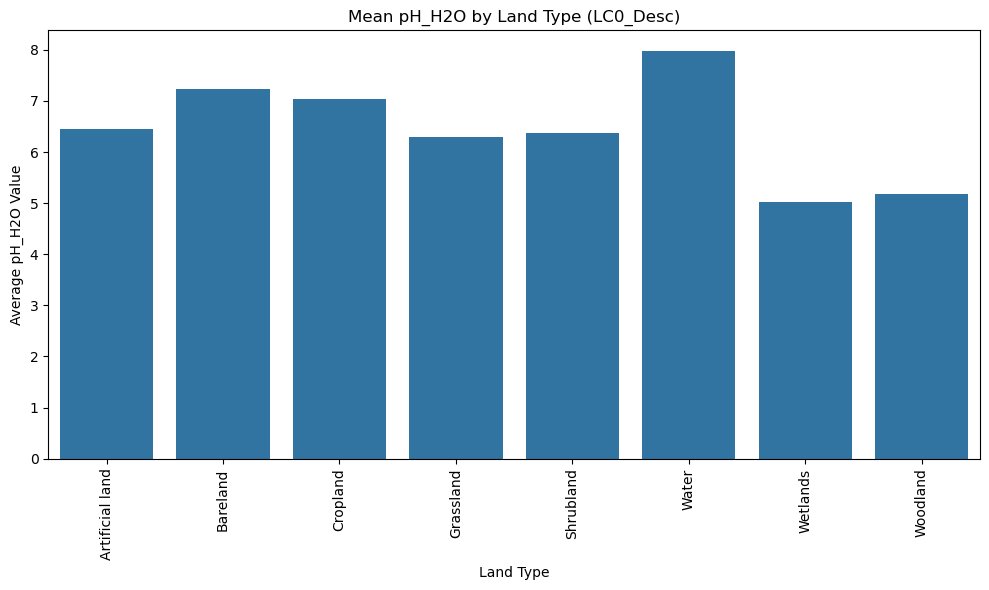

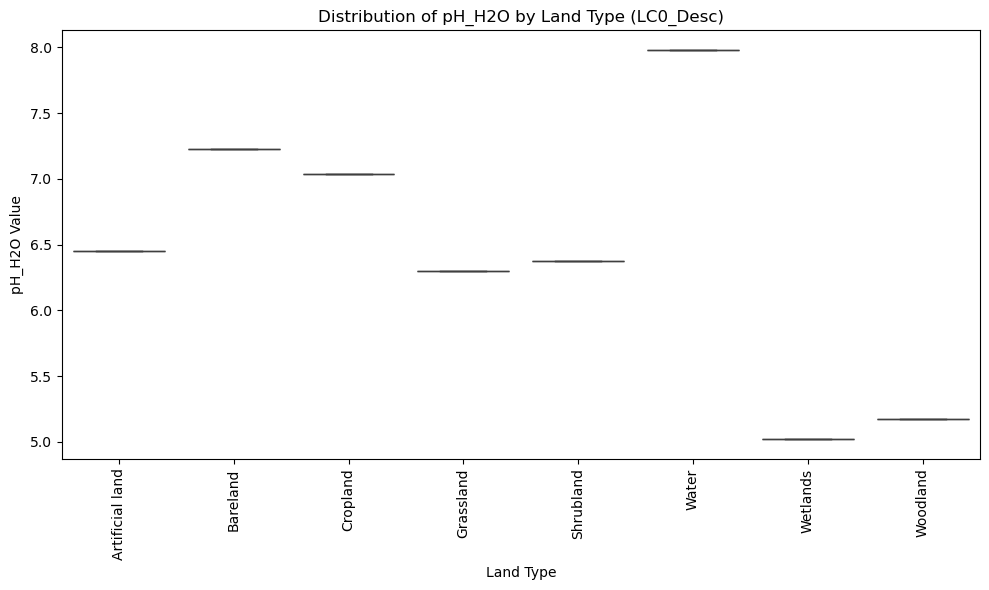

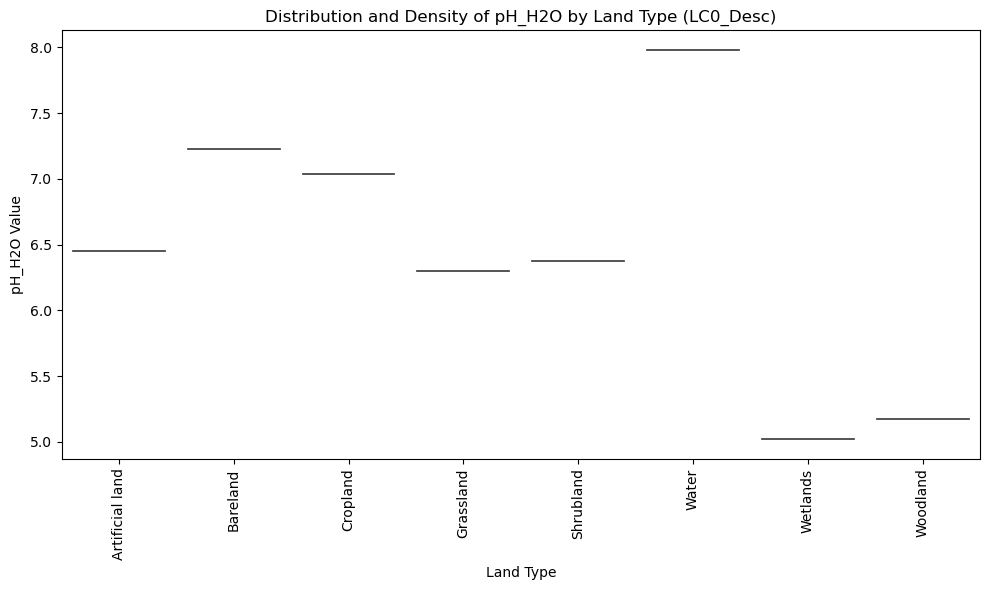

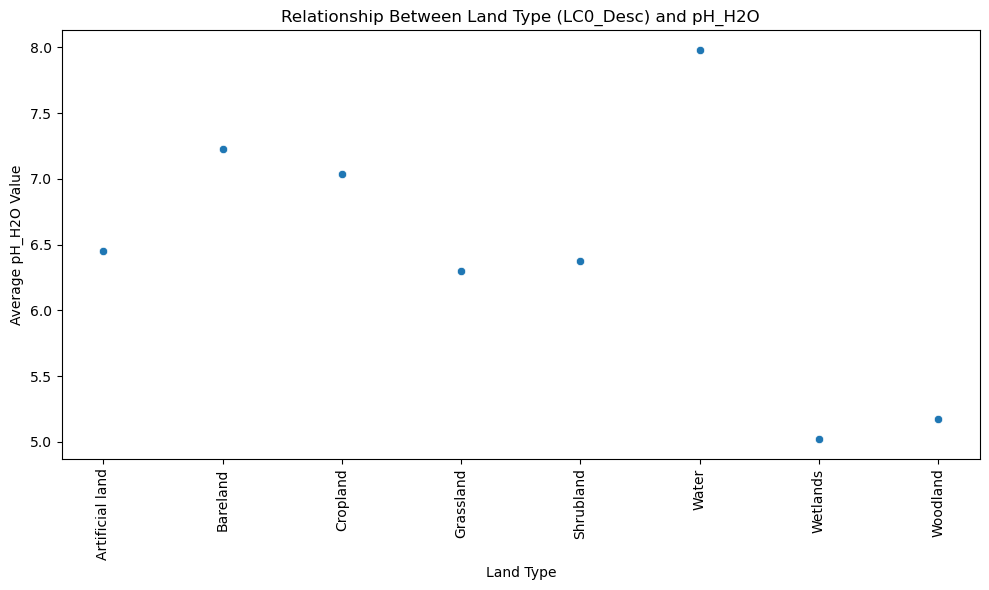

2025-02-04 23:59:48,191 - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


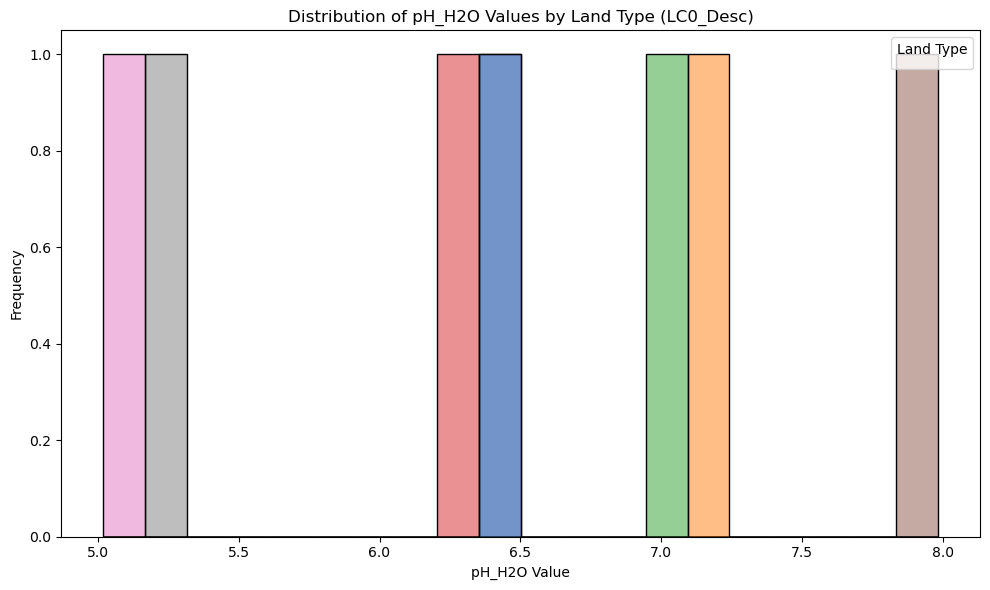

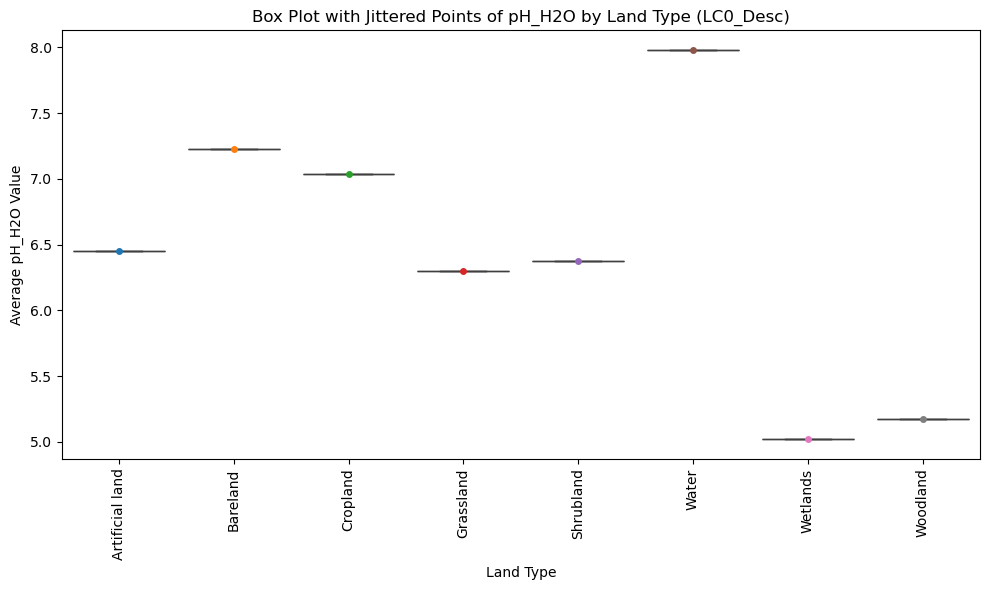

2025-02-04 23:59:48,700 - Using default tokenizer.


Plots saved successfully!

QUERY:  Can you calculate the p-value for the correlation between phosphorus (P) and potassium (K), and determine if the relationship is statistically significant?



2025-02-04 23:59:59,235 - Query finished successfully, response: 
```python
import pandas as pd

# Filter the data to include only rows where 'K' (potassium) is not missing and Depth is 0-20 cm
transformed_gdf = data_gdf[(data_gdf['Depth'] == '0_10') | (data_gdf['Depth'] == '10_20')]
transformed_gdf = transformed_gdf.dropna(subset=['K'])

# Calculate the correlation between phosphorus (P) and potassium (K)
correlation_coefficient, p_value = stats.pearsonr(transformed_gdf['P'], transformed_gdf['K'])
```
2025-02-04 23:59:59,243 - Error while running transform query: `x` and `y` must have length at least 2.
2025-02-05 00:00:10,977 - Query finished successfully, response: 
```python
import pandas as pd
from scipy.stats import pearsonr

# Filter the data to include only rows where 'K' (potassium) is not missing and Depth is 0-20 cm
transformed_gdf = data_gdf[(data_gdf['Depth'] == '0_10') | (data_gdf['Depth'] == '10_20')]
transformed_gdf = transformed_gdf.dropna(subset=['K'])

# Filter the d

         Depth   POINTID  pH_CaCl2  pH_H2O      EC    OC  CaCO3      P     N  \
2      0-20 cm  47982688       4.1    4.85   12.53  47.5    1.0   12.3   3.1   
5      0-20 cm  48122730       6.3    6.81   14.46  18.0    NaN   68.0   2.0   
6      0-20 cm  48202738       5.8    6.37   17.08  12.5    NaN   58.1   1.4   
7      0-20 cm  48222780       7.1    7.98   23.55  22.9   96.0   17.5   2.1   
8      0-20 cm  48342774       7.4    8.09   22.61  29.1   86.0   62.2   2.9   
...        ...       ...       ...     ...     ...   ...    ...    ...   ...   
18979  0-20 cm  32643634       6.0    6.13   91.40  51.4    2.0   92.2   5.3   
18980  0-20 cm  32703676       4.9    5.14   51.78  73.9    NaN   81.6   6.9   
18981  0-20 cm  32783608       5.5    5.94   22.40  63.7    1.0  101.9   6.7   
18982  0-20 cm  32783636       5.3    5.90   10.42  38.3    1.0    7.3   3.1   
18983  0-20 cm  33023682       4.7    4.97  141.70  98.7    1.0   33.7  10.1   

            K  ...  Elev   LC    LU   L

2025-02-05 00:00:30,242 - Query finished successfully, response: 
graph
2025-02-05 00:00:43,071 - Query finished successfully, response: 
```python
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the correlation between phosphorus (P) and potassium (K)
transformed_gdf['Correlation_P_K'] = transformed_gdf.apply(lambda row: row.P * row.K, axis=1)

# Plot a scatter plot of P vs K with regression line
plt.figure(figsize=(10, 8))
sns.regplot(x='P', y='K', data=transformed_gdf)
plt.title('Relationship between Phosphorus (P) and Potassium (K)')
plt.xlabel('Phosphorus (mg/kg)')
plt.ylabel('Potassium (mg/kg)')
plt.show()

# Calculate the p-value for the correlation
p_value = transformed_gdf['Correlation_P_K'].corrwith(transformed_gdf['K']).iloc[0, 1]
print(f'P-value: {p_value}')

# Plot a histogram of P values to check if relationship is statistically significant
plt.figure(figsize=(10, 8))
sns.histplot(transformed_gdf['Correlation_P_K'], kde=True)
plt.title('Histogram of Corre

         Depth   POINTID  pH_CaCl2  pH_H2O      EC    OC  CaCO3      P     N  \
2      0-20 cm  47982688       4.1    4.85   12.53  47.5    1.0   12.3   3.1   
5      0-20 cm  48122730       6.3    6.81   14.46  18.0    NaN   68.0   2.0   
6      0-20 cm  48202738       5.8    6.37   17.08  12.5    NaN   58.1   1.4   
7      0-20 cm  48222780       7.1    7.98   23.55  22.9   96.0   17.5   2.1   
8      0-20 cm  48342774       7.4    8.09   22.61  29.1   86.0   62.2   2.9   
...        ...       ...       ...     ...     ...   ...    ...    ...   ...   
18979  0-20 cm  32643634       6.0    6.13   91.40  51.4    2.0   92.2   5.3   
18980  0-20 cm  32703676       4.9    5.14   51.78  73.9    NaN   81.6   6.9   
18981  0-20 cm  32783608       5.5    5.94   22.40  63.7    1.0  101.9   6.7   
18982  0-20 cm  32783636       5.3    5.90   10.42  38.3    1.0    7.3   3.1   
18983  0-20 cm  33023682       4.7    4.97  141.70  98.7    1.0   33.7  10.1   

            K  ...  Elev   LC    LU   L

<Figure size 640x480 with 0 Axes>

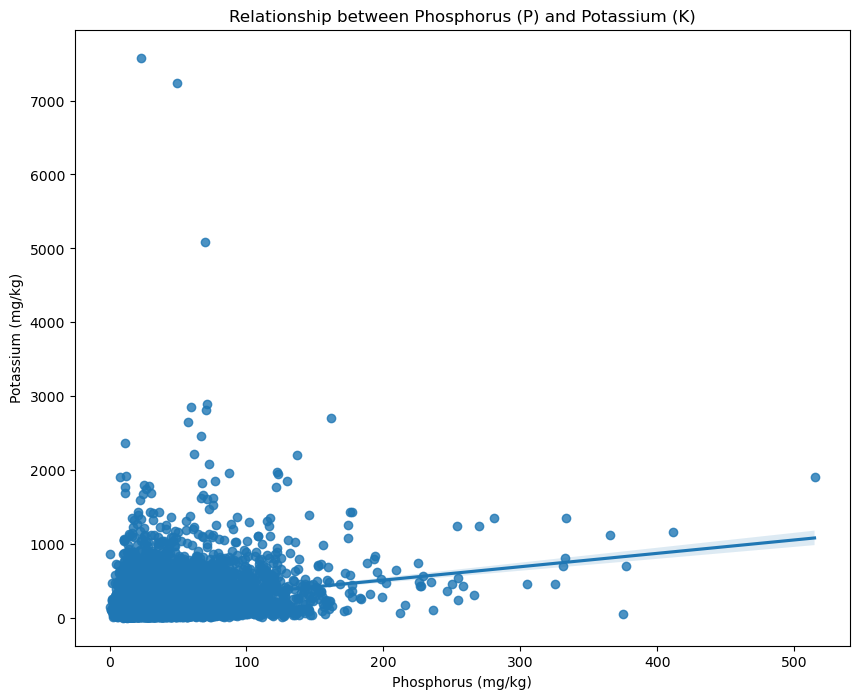

2025-02-05 00:00:44,657 - Error while running visualize query: 'Series' object has no attribute 'corrwith'
2025-02-05 00:00:44,659 - Error while running visualize query: 'Series' object has no attribute 'corrwith'



QUERY:  Are nitrogen 'N' levels different between France and Austria?



2025-02-05 00:00:53,051 - Query finished successfully, response: 
```python
# Filter the data for France and Austria
france_data = data_gdf[data_gdf['Country'] == 'France']
austria_data = data_gdf[data_gdf['Country'] == 'Austria']

# Calculate nitrogen levels for each country
nitrogen_levels_france = france_data[['N']]
nitrogen_levels_austria = austria_data[['N']]

# Store the results in new GeoDataFrames
transformed_gdf_nitrogen_fr = pd.DataFrame(nitrogen_levels_france)
transformed_gdf_nitrogen_at = pd.DataFrame(nitrogen_levels_austria)

# Ensure that both transformed GeoDataFrames have the same columns and data types as 'data_gdf'
transformed_gdf_nitrogen_fr['geometry'] = france_data[['geometry']]
transformed_gdf_nitrogen_at['geometry'] = austria_data[['geometry']]
```
2025-02-05 00:00:53,064 - Error while running transform query: name 'transformed_gdf' is not defined
2025-02-05 00:01:00,429 - Query finished successfully, response: 
```python
# Filter the data for France and Austria



QUERY:  Which parameter among {pH_CaCl2, pH_H2O, OC, CaCO3, P, N, K} is most closely related to EC?



2025-02-05 00:02:27,227 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Create a copy of the original GeoDataFrame to avoid modifying it directly
transformed_gdf = data_gdf.copy()

# Filter out rows where EC is missing or has invalid values (i.e., below LOD)
transformed_gdf = transformed_gdf[~(transformed_gdf['EC'].isnull()) & 
                                 ((transformed_gdf['EC'] >= 0.1) | (pd.isna(transformed_gdf['EC'])))]

# Select the columns of interest for correlation analysis
columns_of_interest = ['pH_CaCl2', 'pH_H2O', 'OC', 'CaCO3', 'P', 'N', 'K']

# Calculate pairwise correlations between EC and other variables in the filtered GeoDataFrame
correlation_matrix = transformed_gdf[columns_of_interest].corr()

# Identify the variable with the highest absolute correlation coefficient (|r|)
most_related_var = columns_of_interest[np.argmax(np.abs(correlation_matrix['EC']))]

transformed_gdf['MostRelatedVar'] = most_related_var


QUERY:  Is there a difference in potassium 'K' levels between grasslands and croplands?



2025-02-05 00:03:27,905 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only grasslands and croplands
grassland_data = data_gdf[data_gdf['LC0_Desc'] == 'Grassland']
cropland_data = data_gdf[data_gdf['LU1_Desc'] == 'Cropland']

# Create a new GeoDataFrame for each land cover type
transformed_grassland_gdf = grassland_data.copy()
transformed_cropland_gdf = cropland_data.copy()

# Filter the transformed GeoDataFrames to include only rows where K is not missing and Depth is 0-20 cm or 10-30 cm (to match with OC, CaCO3)
transformed_grassland_gdf = transformed_grassland_gdf[(~transformed_grassland_gdf['K'].isnull()) & ((transformed_grassland_gdf['Depth'] == '0_10') | (transformed_grassland_gdf['Depth'] == '20_30'))]
transformed_cropland_gdf = transformed_cropland_gdf[(~transformed_cropland_gdf['K'].isnull()) & ((transformed_cropland_gdf['Depth'] == '0_10') | (transformed_cropland_gdf['Depth'] == '20_30'))]

# 

nan nan


2025-02-05 00:03:51,799 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to include only grasslands and croplands
grassland_data = data_gdf[data_gdf['LC0_Desc'] == 'Grassland']
cropland_data = data_gdf[data_gdf['LU1_Desc'] == 'Cropland']

# Create a new GeoDataFrame for each land cover type
transformed_grassland_gdf = grassland_data.copy()
transformed_cropland_gdf = cropland_data.copy()

# Filter the transformed GeoDataFrames to include only rows where K is not missing and Depth is 0-20 cm or 10-30 cm (to match with OC, CaCO3)
transformed_grassland_gdf = transformed_grassland_gdf[(~transformed_grassland_gdf['K'].isnull()) & ((transformed_grassland_gdf['Depth'] == '0_10') | (transformed_grassland_gdf['Depth'] == '20_30'))]
transformed_cropland_gdf = transformed_cropland_gdf[(~transformed_cropland_gdf['K'].isnull()) & ((transformed_cropland_gdf['Depth'] == '0_10') | (transformed_cropland_gdf['Depth'] == '20_30'))]

# 

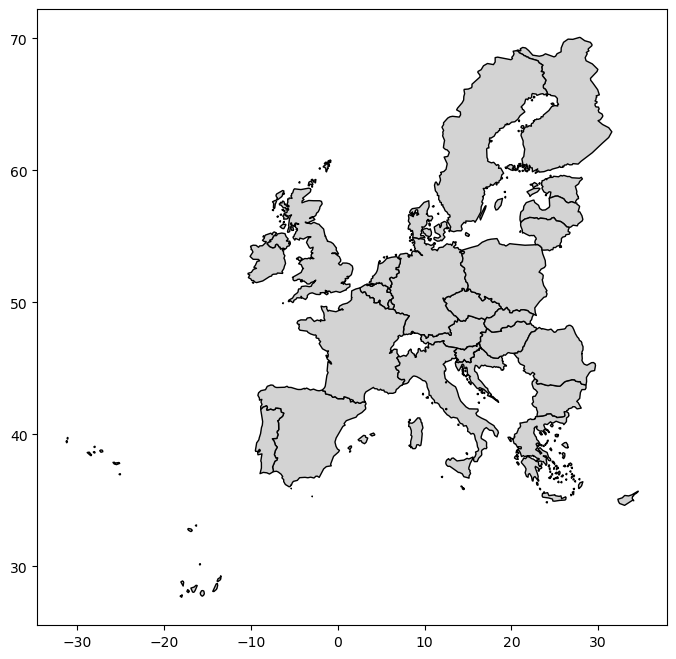

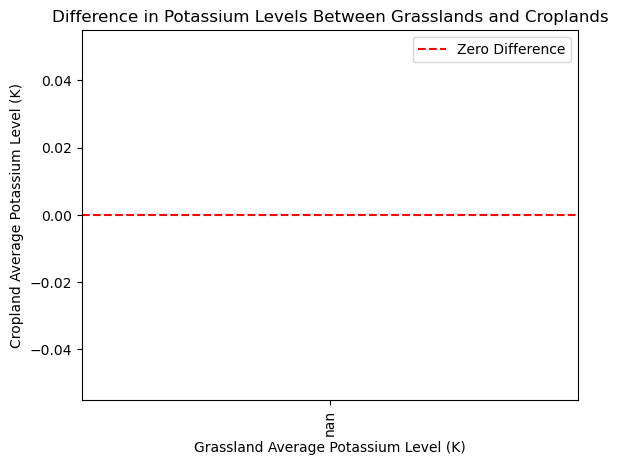

2025-02-05 00:04:09,107 - Using default tokenizer.



QUERY:  Show me how 'pH_H2O' affects potassium 'K' levels in a graph.



In [ ]:
for query_type in ['infer']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        print()
        print("QUERY: ", query, end='\n\n')
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = run_test(query)
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, clean_python_code(generated_result))
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)